In [2]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


MDB 영화 리뷰 데이터를 불러옵니다.

num_words=500 → 가장 자주 등장하는 500개의 단어만 사용

반환값:

train_input → 학습 리뷰 데이터 (단어를 정수로 변환)

train_target → 학습 레이블 (긍정=1, 부정=0)

test_input, test_target → 테스트용 데이터

학습 데이터 중 20%를 검증용 데이터로 분리

random_state=42 → 매번 실행해도 동일하게 분리

결과:

train_input, train_target → 학습용

val_input, val_target → 검증용

In [3]:
from keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

문제: IMDB 리뷰는 길이가 제각각 → RNN/LSTM 같은 모델은 고정 길이 입력 필요

pad_sequences:

길이가 100보다 짧으면 앞쪽에 0으로 패딩

길이가 100보다 길면 뒤쪽을 잘라서(truncate) 길이 맞춤

이제 모든 리뷰가 길이 100의 정수 시퀀스 벡터로 통일됨
train_seq.shape → (학습 샘플 수, 100)

val_seq.shape → (검증 샘플 수, 100)

In [4]:
import keras
model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500,16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

model_lstm = keras.Sequential():
층을 순서대로 쌓는 케라스 모델 생성


model_lstm.add(keras.layers.Input(shape=(100,))):

입력 데이터 형태 지정

각 리뷰는 길이 100인 시퀀스 (앞서 pad_sequences로 맞춤)

단어는 정수 인덱스로 표현됨

model_lstm.add(keras.layers.Input(shape=(100,))):

입력 데이터 형태 지정

각 리뷰는 길이 100인 시퀀스 (앞서 pad_sequences로 맞춤)

단어는 정수 인덱스로 표현됨

model_lstm.add(keras.layers.Embedding(500,16)):

정수 인덱스를 16차원 벡터로 변환

500 → 단어 사전 크기

출력 형태: (batch_size, 100, 16)

model_lstm.add(keras.layers.LSTM(8)):

**순환 신경망(LSTM)**으로 시퀀스 정보 처리

8 → LSTM 출력 차원 (hidden state)

입력: (batch_size, 100, 16)

출력: (batch_size, 8) (마지막 시점의 hidden state)

model_lstm.add(keras.layers.Dense(1, activation='sigmoid')):

1개의 노드로 출력 → 긍정/부정 분류

sigmoid → 0~1 사이 확률


In [5]:
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

LSTM 모델의 구조와 파라미터 수를 요약해서 보여주는 명령

Layer (type) → 각 층의 이름과 종류

Output Shape → 각 층을 통과한 후 데이터 형태

Param # → 각 층의 학습 가능한 파라미터 수

In [6]:
model_lstm.compile(optimizer ='adam', loss = 'binary_crossentropy',
                   metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_lstm.fit(train_seq, train_target, epochs = 100, batch_size=64,
                         validation_data=(val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.6016 - loss: 0.6475 - val_accuracy: 0.7838 - val_loss: 0.4757
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7888 - loss: 0.4639 - val_accuracy: 0.7894 - val_loss: 0.4548
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8000 - loss: 0.4373 - val_accuracy: 0.8030 - val_loss: 0.4312
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.7965 - loss: 0.4306 - val_accuracy: 0.7954 - val_loss: 0.4447
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8115 - loss: 0.4104 - val_accuracy: 0.8040 - val_loss: 0.4319
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8137 - loss: 0.4083 - val_accuracy: 0.8012 - val_loss: 0.4329


모델 컴파일

Adam 옵티마이저 사용

이진 분류용 binary_crossentropy 손실 함수

정확도(accuracy) 지표 확인

콜백 설정

ModelCheckpoint: 검증 손실이 좋아질 때마다 가장 좋은 모델만 저장

EarlyStopping: 3 epoch 동안 개선이 없으면 조기 종료 + 가장 좋은 가중치로 복원

모델 학습

최대 100 epoch 학습

배치 크기 64

검증 데이터로 성능 평가

위 콜백 두 개 적용하여 과적합 방지

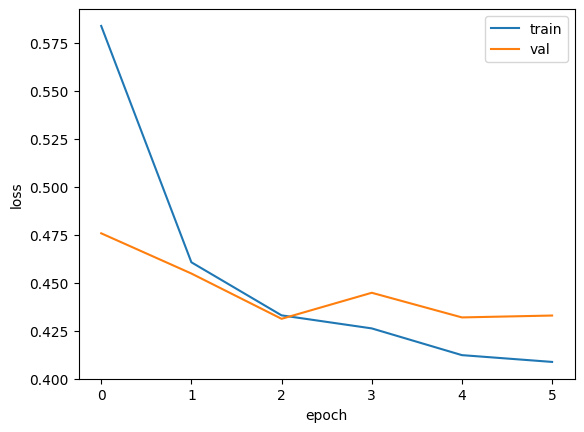

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

history.history['loss']
→ 훈련 손실을 epoch별로 그래프로 그림

history.history['val_loss']
→ 검증 손실을 epoch별로 그래프로 그림

plt.xlabel('epoch')
→ x축 이름: epoch

plt.ylabel('loss')
→ y축 이름: loss(손실 값)

plt.legend()
→ train / val 표시

plt.show()
→ 그래프 화면 출력

In [8]:
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))


Input(shape=(100,))

입력 문장의 길이를 100 토큰으로 가정

Embedding(500, 16)

단어 사전 크기: 500

각 단어를 16차원 벡터로 변환

LSTM(8, dropout=0.2)

LSTM 유닛 수: 8

dropout=0.2 → 내부 뉴런의 20%를 랜덤으로 끄면서 학습

과적합(overfitting) 방지 효과

Dense(1, activation='sigmoid')

출력층

이진 분류(binary classification)에서 사용

결과: 0~1 사이의 확률 출력

In [13]:
model_dropout.compile(optimizer='adam', loss= 'binary_crossentropy',
                      metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                            validation_data = (val_seq, val_target),
                            callbacks =[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.5912 - loss: 0.6617 - val_accuracy: 0.7624 - val_loss: 0.5077
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7763 - loss: 0.4862 - val_accuracy: 0.7698 - val_loss: 0.4782
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7958 - loss: 0.4472 - val_accuracy: 0.7968 - val_loss: 0.4401
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.7996 - loss: 0.4335 - val_accuracy: 0.8012 - val_loss: 0.4302
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8115 - loss: 0.4105 - val_accuracy: 0.7988 - val_loss: 0.4349
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8122 - loss: 0.4070 - val_accuracy: 0.7930 - val_loss: 0.4403
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8161 - loss: 0.4028 - val_accuracy: 0.8056 - val_loss: 0.4226
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8188 - loss: 0

Adam 옵티마이저 사용

이진 분류용 손실 함수(binary_crossentropy)

accuracy 측정

검증 손실이 가장 낮았던 최고 성능 모델만 저장

검증 손실이 3 epoch 동안 좋아지지 않으면 학습을 자동으로 중단

최고 성능의 가중치를 자동으로 복원

최대 100 epoch 훈련

하지만 early stopping 때문에 보통 더 일찍 종료

validation loss와 accuracy도 함께 기록

history 변수에 훈련 기록 저장됨 → 그래프 그릴 때 사용

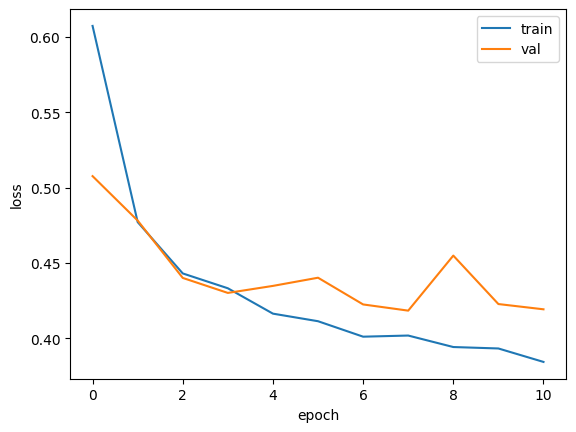

In [14]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

학습 데이터에서의 손실값(오차)을 epoch마다 기록

검증 데이터에서의 손실값(오차)을 epoch마다 기록

두 개의 손실 값을 그래프로 그림

train: 파란색

val: 주황색

x축 이름 = epoch

y축 이름 = loss(손실 값)

In [17]:
model_21stm = keras.Sequential()
model_21stm.add(keras.layers.Input(shape=(100,)))
model_21stm.add(keras.layers.Embedding(500, 16))
model_21stm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_21stm.add(keras.layers.LSTM(8, dropout=0.2))
model_21stm.add(keras.layers.Dense(1, activation='sigmoid'))
model_21stm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

입력 시퀀스 길이 100

단어 500개 → 16차원 벡터

첫 번째 LSTM 층:
유닛 8개, 드롭아웃 20% → 과적합 방지

return_sequences=True → 전체 시퀀스 출력 → 다음 LSTM 층으로 전달

두 번째 LSTM 층:
두 번째 LSTM 층, 마지막 출력만 Dense로 전달

return_sequences=False → 기본값, 마지막 상태만 반환

이진 분류용

출력값 0~1 → 확률로 해석 가능

In [18]:
model_21stm.compile(optimizer='adam', loss='binary_crossentropy',
                    metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-21stm-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_21stm.fit(train_seq, train_target, epochs=100, batch_size=64,
                          validation_data=(val_seq, val_target),
                          callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.6009 - loss: 0.6459 - val_accuracy: 0.7712 - val_loss: 0.4900
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.7673 - loss: 0.4983 - val_accuracy: 0.7864 - val_loss: 0.4558
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.7898 - loss: 0.4547 - val_accuracy: 0.7564 - val_loss: 0.5052
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.7901 - loss: 0.4499 - val_accuracy: 0.7916 - val_loss: 0.4481
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8055 - loss: 0.4288 - val_accuracy: 0.7874 - val_loss: 0.4462
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.8105 - loss: 0.4214 - val_accuracy: 0.8026 - val_loss: 0.4287
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8042 - loss: 0.4234 - val_accuracy: 0.8052 - val_loss: 0.4382
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8064 - loss: 0

Adam 옵티마이저: 학습률 자동 조절

binary_crossentropy: 이진 분류 손실 함수

accuracy: 정확도 지표 확인

검증 손실이 가장 낮을 때 최고 성능 모델 저장

검증 손실이 3 epoch 동안 개선되지 않으면 학습 자동 종료

최고 성능 가중치 자동 복원

최대 100 epoch 학습, 배치 크기 64

**검증 데이터(val_seq, val_target)**로 성능 확인

콜백 적용 → 과적합 방지 + 최고 모델 저장

학습 기록(history) → 손실(loss), 정확도(accuracy) 저장

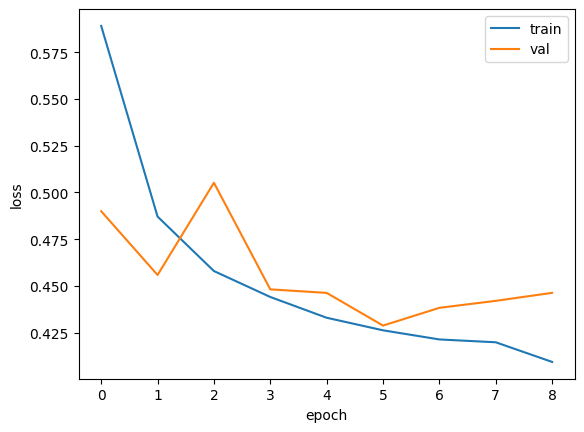

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

파란선(train): 학습 데이터에서의 손실 변화

주황선(val): 검증 데이터에서의 손실 변화

선이 내려갈수록 모델이 학습되고 있다는 의미

val_loss가 올라가기 시작하면 과적합 신호

In [20]:
model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

(100,) → 한 문장이 최대 100개의 토큰으로 구성됨

시퀀스 형태로 GRU가 순서대로 처리

단어 사전 500개, 각 단어를 16차원 벡터로 변환

텍스트 → GRU가 처리 가능한 숫자 벡터

유닛 8개, 드롭아웃 20% → 과적합 방지

LSTM과 달리 구조가 더 단순하고 계산이 빠름

마지막 상태만 출력 (Dense로 전달)

이진 분류용

출력값 0~1 → 확률로 해석 가능

In [21]:
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

GRU 모델의 층 구조와 학습 가능한 파라미터 수 확인가능


Embedding Layer

입력: 100개의 토큰

단어 사전 500개 → 16차원 벡터

파라미터 수 = 500 × 16 = 8,000

GRU Layer

유닛 8개, 드롭아웃 0.2 적용

입력과 GRU 내부 가중치 포함해서 파라미터 624개

Dense Layer

이진 분류 출력층

입력 8개 × 출력 1 + bias 1 = 9 파라미터

In [22]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks = [checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.5831 - loss: 0.6609 - val_accuracy: 0.7662 - val_loss: 0.4879
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.7666 - loss: 0.4951 - val_accuracy: 0.7658 - val_loss: 0.4889
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7903 - loss: 0.4578 - val_accuracy: 0.7876 - val_loss: 0.4528
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.7992 - loss: 0.4340 - val_accuracy: 0.7872 - val_loss: 0.4520
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.8001 - loss: 0.4366 - val_accuracy: 0.7912 - val_loss: 0.4494
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.7999 - loss: 0.4363 - val_accuracy: 0.7950 - val_loss: 0.4376
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8043 - loss: 0.4278 - val_accuracy: 0.8026 - val_loss: 0.4312
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8051 - loss: 0

Adam 옵티마이저: 학습률 자동 조절

binary_crossentropy: 이진 분류 손실 함수

accuracy: 정확도 지표 확인

검증 손실이 가장 낮을 때 최고 성능 모델 저장

검증 손실이 3 epoch 동안 개선되지 않으면 학습 자동 종료

최고 성능 가중치 자동 복원

최대 100 epoch 학습, 배치 크기 64

검증 데이터로 성능 확인

콜백 적용 → 과적합 방지 + 최고 모델 저장

학습 기록(history) → 손실(loss), 정확도(accuracy) 저장

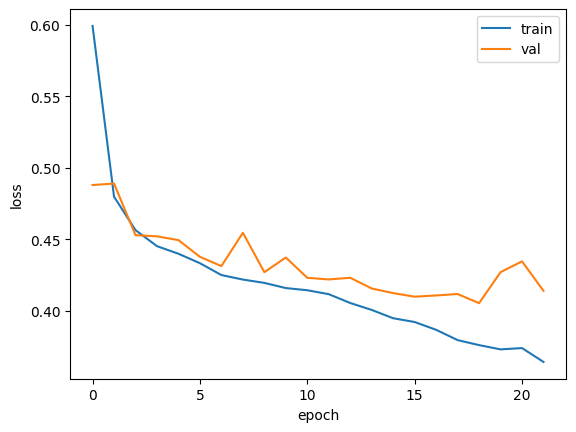

In [23]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

파란선(train): 학습 데이터에서의 손실 변화

주황선(val): 검증 데이터에서의 손실 변화

선이 내려갈수록 모델이 학습되고 있다는 의미

val_loss가 올라가기 시작하면 과적합 신호

In [24]:
test_seq = pad_sequences(test_input, maxlen=100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8199 - loss: 0.4034


[0.401450514793396, 0.8184000253677368]

테스트 데이터(test_input)를 훈련 때 사용한 길이 100에 맞춰 패딩

LSTM/GRU는 입력 길이가 같아야 하기 때문에 필요

가장 성능이 좋았던 GRU 모델을 파일에서 로드

학습 후 저장해둔 ModelCheckpoint 모델 사용

테스트 데이터(test_seq, test_target)로 손실(loss)과 정확도(accuracy) 확인

반환값: [loss, accuracy]
손실 0.42, 정확도 87%